## AIM

The aim of this project is to analyze manufacturing process and machine operational data using Python to identify inefficiencies, abnormal patterns, and factors contributing to machine failures. The project focuses on applying data analysis and statistical techniques to improve operational reliability and support data-driven decision-making.

## BUSINESS PROBLEM

Manufacturing industries often face operational challenges such as machine failures, excessive tool wear, process inefficiencies, and production downtime. These issues can reduce productivity, increase maintenance costs, and affect product quality. Without proper data analysis, identifying the root causes of failures and abnormal operational behavior becomes difficult. Therefore, there is a need for an analytical solution that can monitor machine conditions, detect failure patterns, and improve process performance.

## OBJECTIVES

- To analyze manufacturing and machine operational data using Python.
- To perform data cleaning and preprocessing for accurate analysis.
- To identify patterns and trends related to machine failures.
- To apply statistical and exploratory data analysis techniques for operational insights.
- To detect abnormal behavior in machine parameters such as temperature, torque, and tool wear.
- To evaluate relationships between operational variables using correlation analysis.
- To generate meaningful insights for improving manufacturing efficiency and reliability.

## METHODOLOGY

1. Data Collection :

   The manufacturing dataset was collected in CSV format containing machine operational and failure-related parameters.

2. Data Preprocessing :

   The dataset was cleaned using Python libraries such as Pandas and NumPy. Missing values, duplicate records, and inconsistent column names were handled to improve data quality.

3. Exploratory Data Analysis (EDA) :

   EDA techniques were applied to understand the distribution of machine parameters, identify trends, and detect abnormal operational behavior through visualizations and statistical summaries.

4. Statistical Analysis :

   Statistical measures such as mean, standard deviation, and correlation analysis were used to evaluate machine performance and identify relationships among variables.

5. Failure and Operational Analysis :

   Machine failure patterns were analyzed based on factors such as tool wear, rotational speed, torque, and temperature to determine conditions affecting operational reliability.

6. Insight Generation :

   The analyzed results were interpreted to generate actionable insights and recommendations for improving manufacturing process efficiency and reducing operational failures.

## DATA DESCRIPTION


- Number of Rows: 10,000  
- Number of Columns: 14  

The dataset contains manufacturing machine operational data and failure-related parameters used for analyzing machine performance, operational efficiency, and failure patterns.

| Attribute | Description |
|---|---|
| UDI | Unique identifier for each record |
| Product ID | Product identification code |
| Type | Product type/category |
| Air Temperature [K] | Ambient air temperature in Kelvin |
| Process Temperature [K] | Internal process temperature in Kelvin |
| Rotational Speed [rpm] | Machine rotational speed in revolutions per minute |
| Torque [Nm] | Rotational force generated by the machine |
| Tool Wear [min] | Tool usage duration in minutes |
| Machine Failure | Indicates whether machine failure occurred |
| TWF | Tool wear failure |
| HDF | Heat dissipation failure |
| PWF | Power failure |
| OSF | Overstrain failure |
| RNF | Random failure |

## IMPORTING LIBRARIES

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Statistical Analysis
from scipy import stats

# Machine Learning Utilities (Optional for Future Extension)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Visualization Style
sns.set_style('whitegrid')


## DATA LOADING

In [2]:
df=pd.read_csv("ai4i2020.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

## DATA CLEANING

In [7]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
## Rename the column names for sql and powerbi part.

df.rename(columns={
    'Product ID': 'Product_ID',
    'Air temperature [K]':'Air_Temp',
    'Process temperature [K]':'Process_Temp',
    'Rotational speed [rpm]':'Rotational_Speed',
    'Torque [Nm]':'Torque',
    'Tool wear [min]':'Tool_Wear',
    'Machine failure':'Machine_Failure'
}, inplace=True)

In [10]:
df.columns

Index(['UDI', 'Product_ID', 'Type', 'Air_Temp', 'Process_Temp',
       'Rotational_Speed', 'Torque', 'Tool_Wear', 'Machine_Failure', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

## EDA

In [11]:
df.describe()

,UDI,Air_Temp,Process_Temp,Rotational_Speed,Torque,Tool_Wear,Machine_Failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


**MACHINE FAILURE ANALYSIS**

In [12]:
# Failure Count
print("\nMachine Failure Count:")
print(df['Machine_Failure'].value_counts())



Machine Failure Count:
Machine_Failure
0    9661
1     339
Name: count, dtype: int64


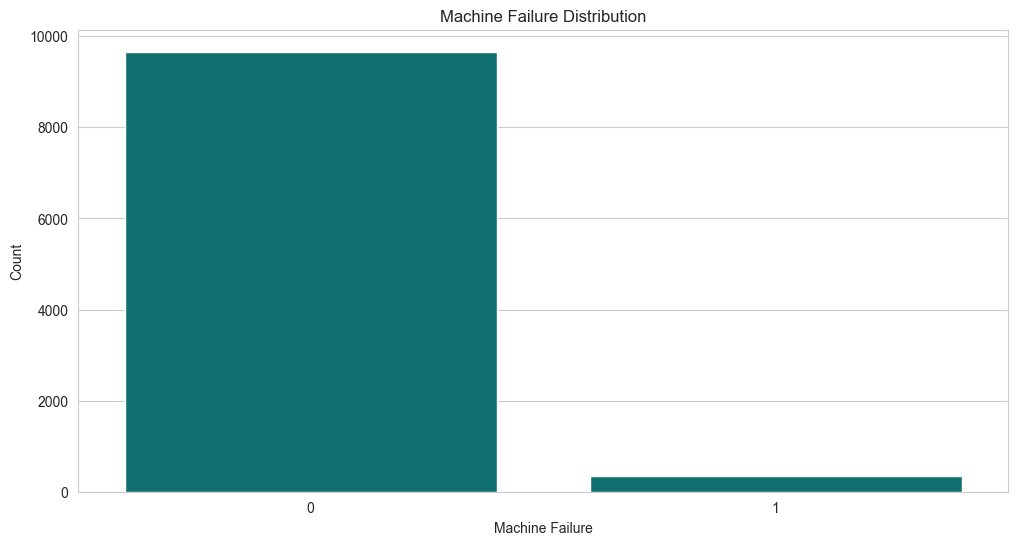

In [13]:
# Visualization
plt.figure(figsize=(12,6))
sns.countplot(x='Machine_Failure', data=df,color='Teal')

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()


**FAILURE RATE ANALYSIS**

In [14]:
# Calculate Failure Rate
failure_rate = (df['Machine_Failure'].sum()/len(df))*100

print("Failure Rate:", round(failure_rate,2), "%")

Failure Rate: 3.39 %


**CORRELATION ANALYSIS**

In [15]:
# Correlation Matrix
correlation_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                       UDI  Air_Temp  Process_Temp  Rotational_Speed  \
UDI               1.000000  0.117428      0.324428         -0.006615   
Air_Temp          0.117428  1.000000      0.876107          0.022670   
Process_Temp      0.324428  0.876107      1.000000          0.019277   
Rotational_Speed -0.006615  0.022670      0.019277          1.000000   
Torque            0.003207 -0.013778     -0.014061         -0.875027   
Tool_Wear        -0.010702  0.013853      0.013488          0.000223   
Machine_Failure  -0.022892  0.082556      0.035946         -0.044188   
TWF               0.009154  0.009955      0.007315          0.010389   
HDF              -0.022215  0.137831      0.056933         -0.121241   
PWF              -0.023557  0.003470     -0.003355          0.123018   
OSF              -0.000990  0.001988      0.004554         -0.104575   
RNF              -0.005954  0.017688      0.022279         -0.013088   

                    Torque  Tool_Wear  Mac

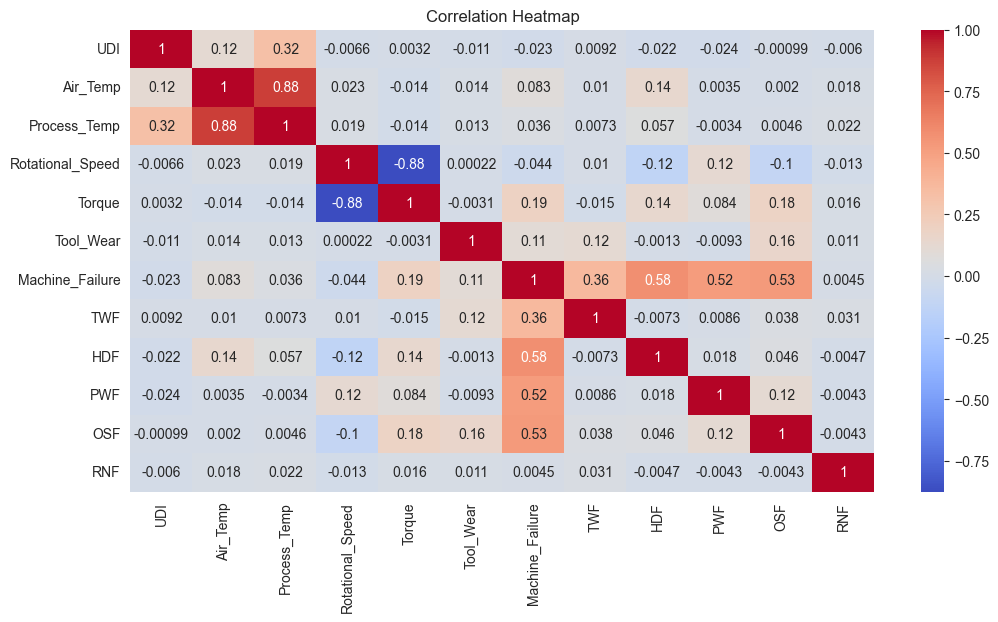

In [16]:
# Correlation Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()



**PROCESS TEMPERATURE ANALYSIS**

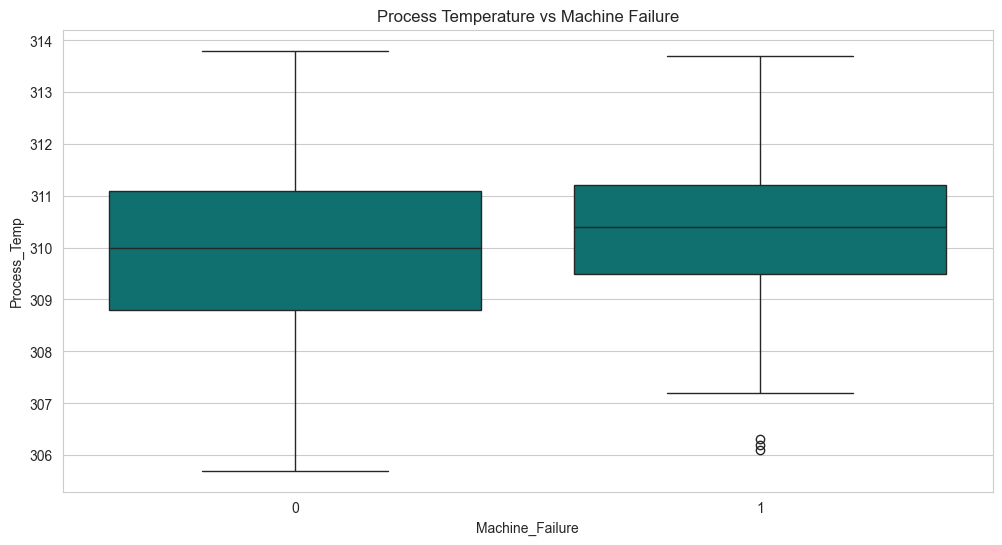

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Machine_Failure',
            y='Process_Temp',
            data=df,color='Teal')

plt.title("Process Temperature vs Machine Failure")
plt.show()

**TOOL WEAR ANALYSIS**

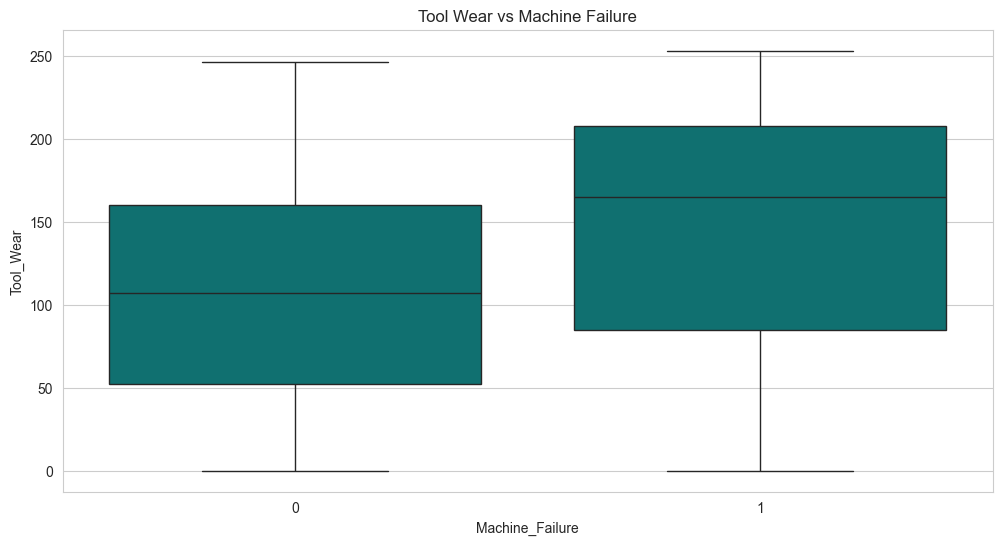

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Machine_Failure',
            y='Tool_Wear',
            data=df,color='Teal')

plt.title("Tool Wear vs Machine Failure")
plt.show()

**ROTATIONAL SPEED ANALYSIS**

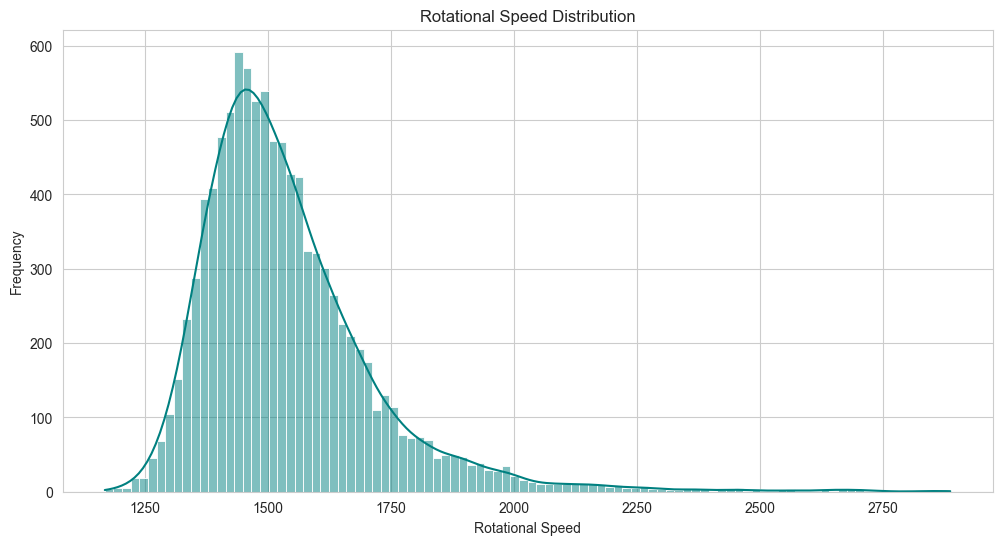

In [19]:
plt.figure(figsize=(12,6))
sns.histplot(df['Rotational_Speed'],
             kde=True, color= 'Teal')

plt.title("Rotational Speed Distribution")
plt.xlabel("Rotational Speed")
plt.ylabel("Frequency")
plt.show()

**TORQUE ANALYSIS**

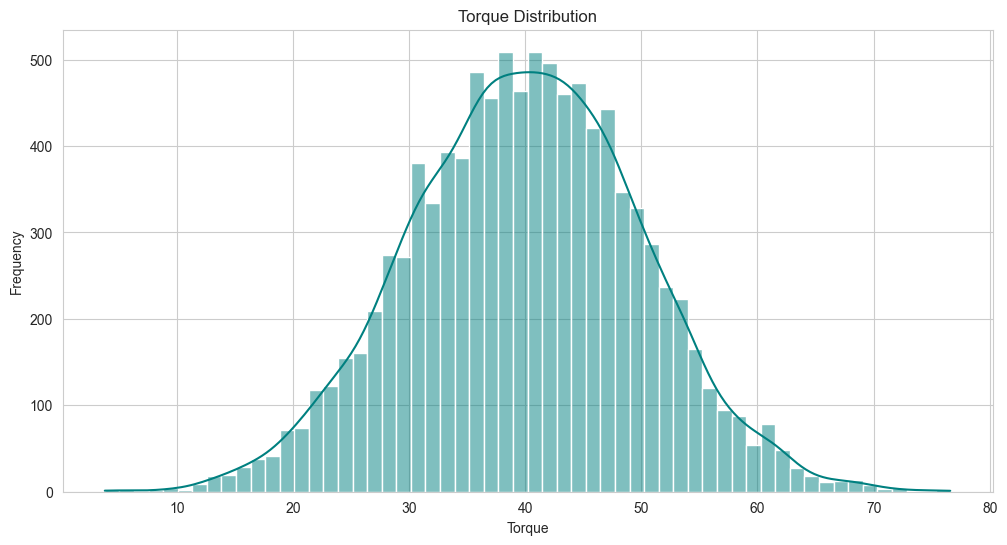

In [20]:
plt.figure(figsize=(12,6))
sns.histplot(df['Torque'],
             kde=True,color='Teal')

plt.title("Torque Distribution")
plt.xlabel("Torque")
plt.ylabel("Frequency")
plt.show()

**ANOMALY DETECTION USING IQR METHOD**

In [21]:
# Calculate Quartiles
Q1 = df['Torque'].quantile(0.25)
Q3 = df['Torque'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect Outliers
outliers = df[
    (df['Torque'] < lower_bound) |
    (df['Torque'] > upper_bound)
]

print("\nNumber of Torque Outliers:", len(outliers))




Number of Torque Outliers: 69


**OUTLIER DETECTION**

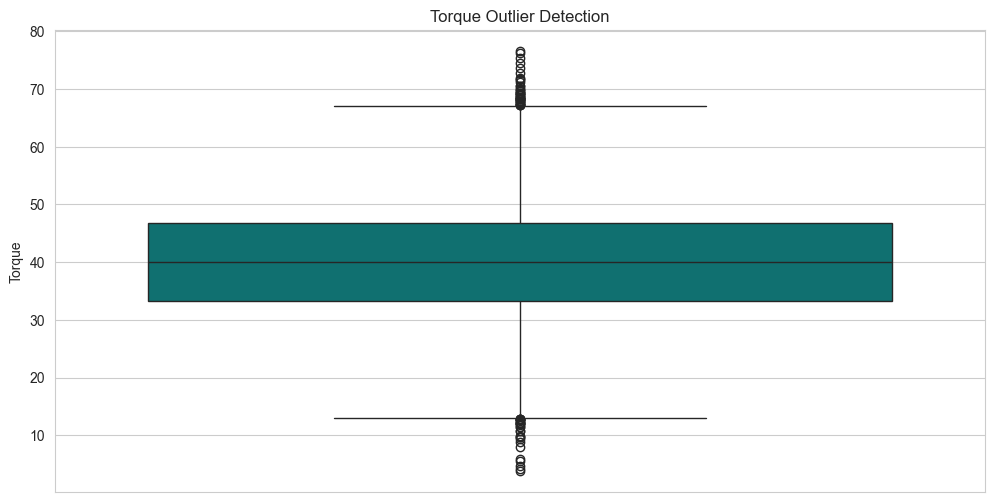

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(df['Torque'],color='Teal')

plt.title("Torque Outlier Detection")
plt.show()


**FAILURE TYPE ANALYSIS**


Failure Type Counts:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


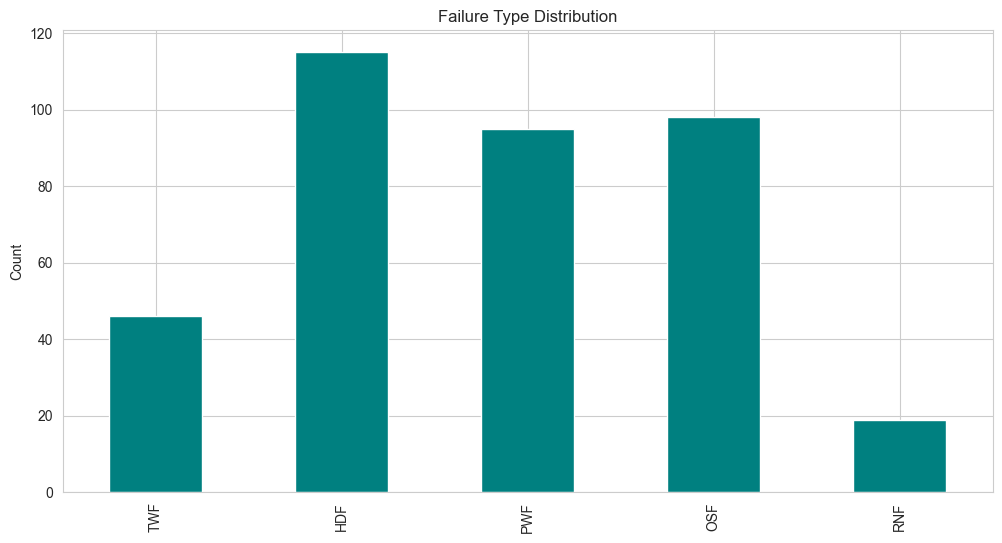

In [23]:
# Failure Columns
failure_columns = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Failure Type Counts
print("\nFailure Type Counts:")
print(df[failure_columns].sum())

# Failure Type Visualization
plt.figure(figsize=(12,6))
df[failure_columns].sum().plot(kind='bar',color='Teal')

plt.title("Failure Type Distribution")
plt.ylabel("Count")
plt.show()

**FEATURE ENGINEERING**

In [24]:
# Create Wear Level Category
df['Wear_Level'] = pd.cut(
    df['Tool_Wear'],
    bins=[0,50,150,300],
    labels=['Low','Medium','High']
)


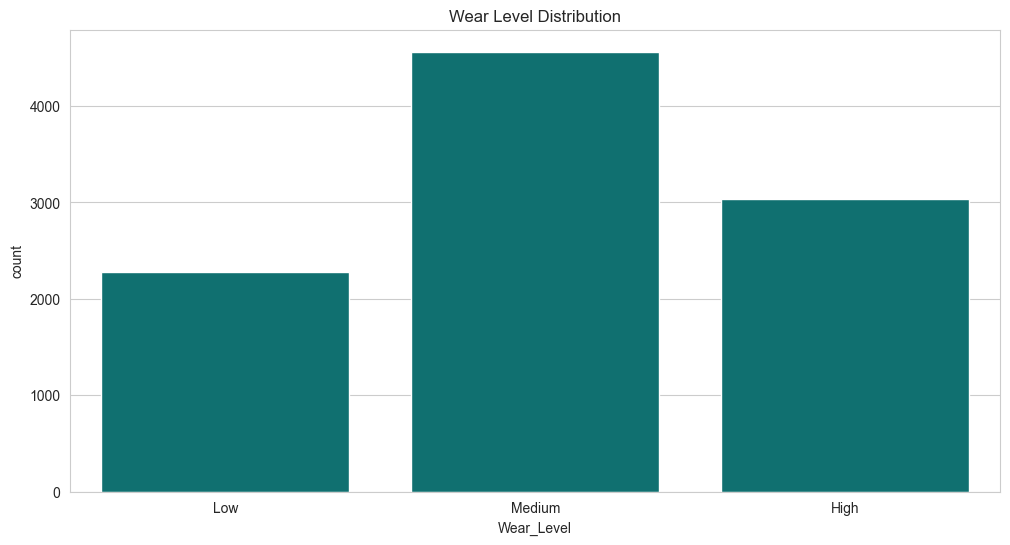

In [25]:
# Wear Level Distribution
plt.figure(figsize=(12,6))
sns.countplot(x='Wear_Level', data=df,color='Teal')

plt.title("Wear Level Distribution")
plt.show()

**PRODUCT TYPE ANALYSIS**

In [26]:
product_analysis = df.groupby('Type')[[
    'Air_Temp',
    'Process_Temp',
    'Torque'
]].mean()

print("\nAverage Operational Parameters by Product Type:")
print(product_analysis)


Average Operational Parameters by Product Type:
        Air_Temp  Process_Temp     Torque
Type                                     
H     299.866999    309.925723  39.838285
L     300.015833    310.012300  39.996600
M     300.029263    310.018785  40.017251


 **MULTIVARIATE ANALYSIS**

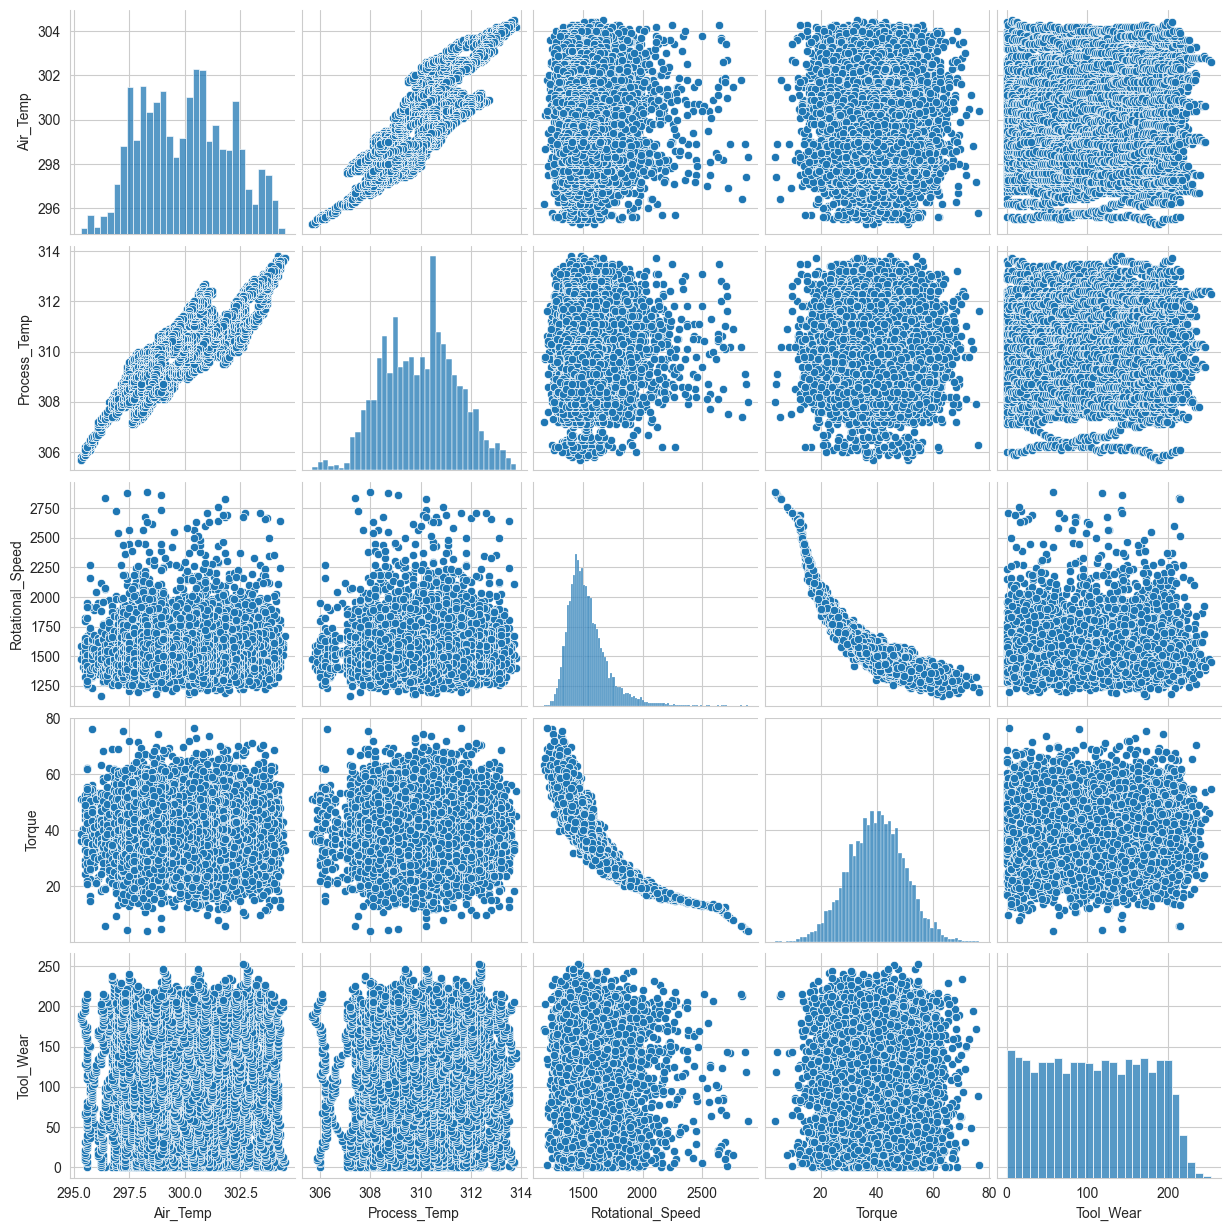

In [27]:
sns.pairplot(df[['Air_Temp',
                 'Process_Temp',
                 'Rotational_Speed',
                 'Torque',
                 'Tool_Wear']])

plt.show()

**OPERATIONAL GAP ANALYSIS**

In [28]:
high_wear_failures = df[
    (df['Tool_Wear'] > 200) &
    (df['Machine_Failure'] == 1)
]

print("\nMachines with High Tool Wear and Failure:")
print(high_wear_failures.shape[0])


Machines with High Tool Wear and Failure:
118


In [29]:
# Save Cleaned Dataset
df.to_csv("cleaned_manufacturing_data.csv",
          index=False)

print("\nCleaned Dataset Saved Successfully")



Cleaned Dataset Saved Successfully


## CONNECTING TO MYSQL SERVER

In [30]:
from sqlalchemy import create_engine
import urllib

# Your SQL Server details
server = r"DESKTOP-A98TCB7\SQLEXPRESS"   # Use raw string for backslash
database = "manufacturing_analysis"            # Your database name
driver = "ODBC Driver 17 for SQL Server"   # Must be installed on your machine

# Build connection string for Windows Authentication
connection_string = urllib.parse.quote_plus(
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

# Create engine
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={connection_string}")

print("✔ Successfully connected to SQL Server (Windows Authentication)!")

✔ Successfully connected to SQL Server (Windows Authentication)!


In [31]:
table_name = "manutacturing_data"   # SQL table name you want to create

df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"✔ Data successfully loaded into table '{table_name}' in database 'manufacturing_analysis'.")

✔ Data successfully loaded into table 'manutacturing_data' in database 'manufacturing_analysis'.
